In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

from DeepSurvAtencjuszClass import AttentionDeepSurv

In [3]:
#%pip install pycox torchtuples torch scikit-learn matplotlib pandas numpy

import torch
import torchtuples as tt
from pycox.models import CoxPH
from pycox.evaluation import EvalSurv

In [39]:
#from Preprocessing.PreprocessingBrainCancer import prepare_brain_cancer_data as prepare_data
#from Preprocessing.PreprocessingBreastCancer import prepare_breast_cancer_data as prepare_data
#from Preprocessing.PreprocessingLeukemia import prepare_leukemia_data as prepare_data 
#from Preprocessing.PreprocessingLungCancer import prepare_lung_cancer_data as prepare_data
#from Preprocessing.PreprocessingLymphoma import prepare_lymphoma_data as prepare_data
#from Preprocessing.PreprocessingProstateCancer import prepare_prostate_cancer_data as prepare_data
from Preprocessing.PreprocessingSmallIntestineCancer import prepare_small_intestine_cancer_data as prepare_data

x_train, y_train, val_data, x_test, y_test = prepare_data("C:\\Users\\kubap\\OneDrive\\Pulpit\\magisterka ekperymenty\\Datasets\\_SmallIntestineCancerUsaDataset.csv")

#laptop
# C:\\Users\\kubap\\Desktop\\magisterka ekperymenty\\Datasets\\

#komputer dom
# C:\\Users\\kubap\\OneDrive\\Pulpit\\magisterka ekperymenty\\Datasets\\

Dane wczytane. Rozmiar początkowy: (21347, 24)

Rozmiar X_train: (12615, 67)


In [40]:
in_features = x_train.shape[1]

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# inicjalizacja sieci - 2 warstwy ukryte po 32 neurony, dropout 0.5
net = AttentionDeepSurv(in_features=in_features, num_nodes=[32, 32], dropout=0.5)

# optymalizator z karą L2 (ochrona przed przeuczeniem)
optimizer = tt.optim.Adam(weight_decay=0.01)

# podpięcie pod CoxPH w pycox
model = CoxPH(net, optimizer, device=device)
model.optimizer.set_lr(0.0001)

Rozpoczęcie uczenia modelu DeepSurv...
0:	[0s / 0s],		train_loss: 4.8343,	val_loss: 7.5375
1:	[0s / 0s],		train_loss: 4.8458,	val_loss: 7.5293
2:	[0s / 0s],		train_loss: 4.8194,	val_loss: 7.5195
3:	[0s / 1s],		train_loss: 4.8270,	val_loss: 7.5092
4:	[0s / 1s],		train_loss: 4.9552,	val_loss: 7.5020
5:	[0s / 1s],		train_loss: 4.8594,	val_loss: 7.4915
6:	[0s / 2s],		train_loss: 4.7663,	val_loss: 7.4882
7:	[0s / 2s],		train_loss: 4.7269,	val_loss: 7.4794
8:	[0s / 2s],		train_loss: 4.7185,	val_loss: 7.4702
9:	[0s / 2s],		train_loss: 4.7802,	val_loss: 7.4714
10:	[0s / 3s],		train_loss: 4.7049,	val_loss: 7.4613
11:	[0s / 3s],		train_loss: 4.7144,	val_loss: 7.4460
12:	[0s / 3s],		train_loss: 4.6842,	val_loss: 7.4366
13:	[0s / 4s],		train_loss: 4.6635,	val_loss: 7.4301
14:	[0s / 4s],		train_loss: 4.6727,	val_loss: 7.4174
15:	[0s / 4s],		train_loss: 4.7398,	val_loss: 7.4128
16:	[0s / 4s],		train_loss: 4.6439,	val_loss: 7.4027
17:	[0s / 5s],		train_loss: 4.6324,	val_loss: 7.3889
18:	[0s / 5s],		t

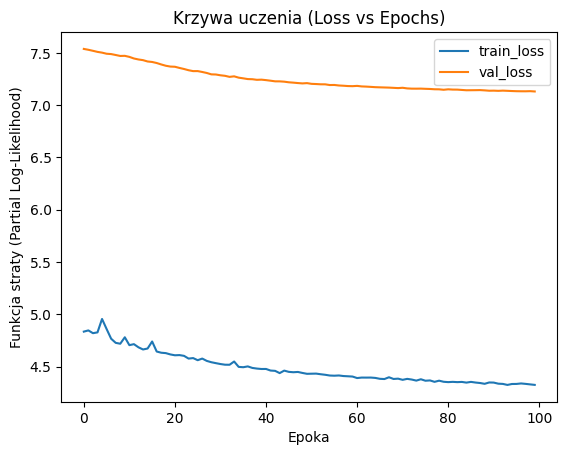

In [41]:
# Uczenie Modelu
batch_size = 256
epochs = 100
callbacks = [tt.callbacks.EarlyStopping(patience=10)]

print("Rozpoczęcie uczenia modelu DeepSurv...")
log = model.fit(x_train, y_train, batch_size, epochs, callbacks, val_data=val_data)

# wykres funkcji straty podczas uczenia
_ = log.plot()
plt.title("Krzywa uczenia (Loss vs Epochs)")
plt.xlabel("Epoka")
plt.ylabel("Funkcja straty (Partial Log-Likelihood)")
plt.show()

In [42]:
# Ewaluacja na zbiorze testowym
_ = model.compute_baseline_hazards()

surv_test = model.predict_surv_df(x_test)

ev = EvalSurv(surv_test, y_test[0], y_test[1], censor_surv='km')

In [44]:
# C-index
c_index = ev.concordance_td()
print(f"Time-Dependent Concordance Index (C-index): {c_index:.4f}")

import scipy.integrate
if not hasattr(scipy.integrate, "simps"):
    scipy.integrate.simps = scipy.integrate.simpson

# Brier Score
time_grid = np.linspace(y_test[0].min(), y_test[0].max(), 100)
brier_score = ev.brier_score(time_grid)
integrated_brier_score = ev.integrated_brier_score(time_grid)
print(f"Integrated Brier Score (IBS): {integrated_brier_score:.4f}")

Time-Dependent Concordance Index (C-index): 0.7781
Integrated Brier Score (IBS): 0.1132


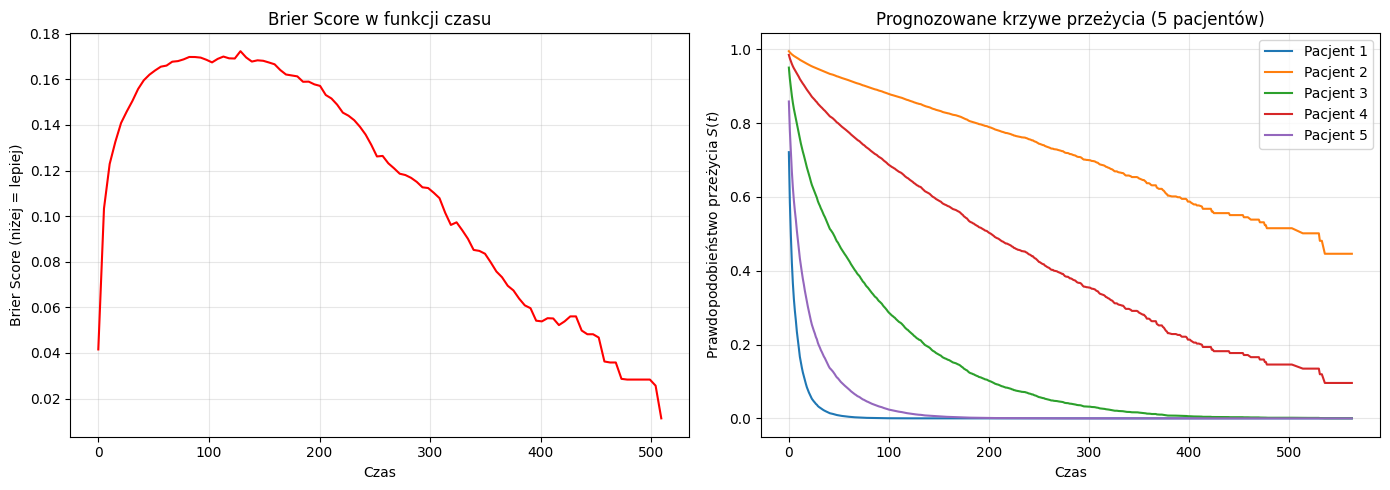

In [45]:
# Wykresy
plt.figure(figsize=(14, 5))

# Wykres Brier Score
plt.subplot(1, 2, 1)
plt.plot(time_grid, brier_score, color='red')
plt.title("Brier Score w funkcji czasu")
plt.xlabel("Czas")
plt.ylabel("Brier Score (niżej = lepiej)")
plt.grid(True, alpha=0.3)

# Wykres krzywe przeżycia dla pierwszych 5 pacjentów ze zbioru testowego
plt.subplot(1, 2, 2)
for i in range(5):
    plt.plot(surv_test.index, surv_test.iloc[:, i], label=f'Pacjent {i+1}')
plt.title("Prognozowane krzywe przeżycia (5 pacjentów)")
plt.xlabel("Czas")
plt.ylabel("Prawdopodobieństwo przeżycia $S(t)$")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

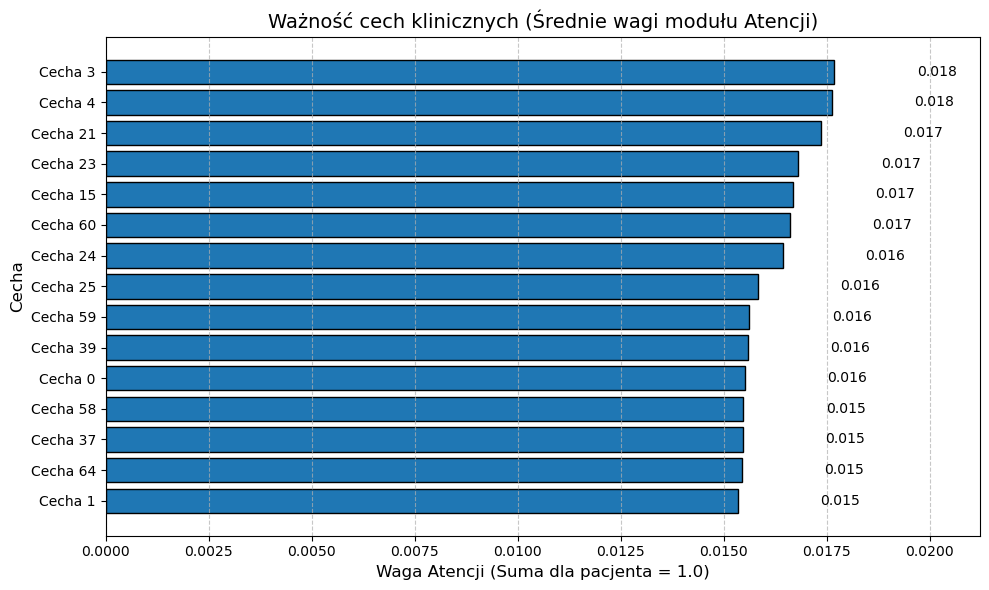

In [68]:
x_test_tensor = torch.tensor(x_test, dtype=torch.float32)

attention_weights = model.net.get_attention_weights(x_test_tensor)

global_importance = attention_weights.mean(dim=0).numpy()

feature_names = [f"Cecha {i}" for i in range(len(global_importance))]

sorted_indices = np.argsort(global_importance)
sorted_importance = global_importance[sorted_indices]
sorted_features = [feature_names[i] for i in sorted_indices]

top_k = 15
if len(sorted_importance) > top_k:
    sorted_importance = sorted_importance[-top_k:]
    sorted_features = sorted_features[-top_k:]

plt.figure(figsize=(10, 6))
bars = plt.barh(sorted_features, sorted_importance, color='#1f77b4', edgecolor='black')

for bar in bars:
    plt.text(
        bar.get_width() + 0.002, 
        bar.get_y() + bar.get_height()/2, 
        f'{bar.get_width():.3f}', 
        va='center', 
        fontsize=10
    )

plt.title("Ważność cech klinicznych (Średnie wagi modułu Atencji)", fontsize=14)
plt.xlabel("Waga Atencji (Suma dla pacjenta = 1.0)", fontsize=12)
plt.ylabel("Cecha", fontsize=12)
plt.xlim(0, max(sorted_importance) * 1.2)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import pandas as pd
import datetime
import os
import matplotlib.pyplot as plt
import torch
import torchtuples as tt

from pycox.evaluation import EvalSurv
from pycox.models import CoxPH

from DeepSurvAtencjuszClass import AttentionDeepSurv

from Preprocessing.PreprocessingBrainCancer import prepare_brain_cancer_data
from Preprocessing.PreprocessingBreastCancer import prepare_breast_cancer_data
from Preprocessing.PreprocessingLeukemia import prepare_leukemia_data
from Preprocessing.PreprocessingLungCancer import prepare_lung_cancer_data
from Preprocessing.PreprocessingLymphoma import prepare_lymphoma_data
from Preprocessing.PreprocessingProstateCancer import prepare_prostate_cancer_data
from Preprocessing.PreprocessingSmallIntestineCancer import prepare_small_intestine_cancer_data

base_path = "C:\\Users\\kubap\\Desktop\\magisterka ekperymenty\\Datasets\\"
datasets = {
    "Brain Cancer": (prepare_brain_cancer_data, base_path + "_BrainCancerUsaDataset.csv"),
    "Breast Cancer": (prepare_breast_cancer_data, base_path + "_BreastCancerUsaDataset.csv"),
    "Leukemia": (prepare_leukemia_data, base_path + "_LeukemiaUsaDataset.csv"),
    "Lung Cancer": (prepare_lung_cancer_data, base_path + "_LungCancerUsaDataset.csv"),
    "Lymphoma": (prepare_lymphoma_data, base_path + "_LymphomaUsaDataset.csv"),
    "Prostate Cancer": (prepare_prostate_cancer_data, base_path + "_ProstateCancerUsaDataset.csv"),
    "Small Intestine Cancer": (prepare_small_intestine_cancer_data, base_path + "_SmallIntestineCancerUsaDataset.csv")
}

output_folder = "Wykresy_Eksperymenty_DSurvAtencjusz"
os.makedirs(output_folder, exist_ok=True)

def run_single_experiment(x_train, y_train, val_data, x_test, y_test):
    in_features = x_train.shape[1]
    
    net = AttentionDeepSurv(in_features=in_features, num_nodes=[32, 32], dropout=0.3)
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    optimizer = tt.optim.Adam(weight_decay=0.01)
    model = CoxPH(net, optimizer, device=device)
    model.optimizer.set_lr(0.0001)
    
    batch_size = 256
    epochs = 100
    callbacks = [tt.callbacks.EarlyStopping(patience=10)]
    
    log = model.fit(x_train, y_train, batch_size, epochs, callbacks, val_data=val_data, verbose=False)
    
    _ = model.compute_baseline_hazards()

    # EWALUACJA
    surv_test = model.predict_surv_df(x_test)
    ev = EvalSurv(surv_test, y_test[0], y_test[1], censor_surv='km')
    c_index = ev.concordance_td()
    
    time_grid = np.linspace(y_test[0].min(), y_test[0].max(), 100)
    ibs = ev.integrated_brier_score(time_grid)
    brier_score_time = ev.brier_score(time_grid)
    
    device_model = next(model.net.parameters()).device
    x_test_tensor = torch.tensor(x_test, dtype=torch.float32).to(device_model)
    attention_weights = model.net.get_attention_weights(x_test_tensor).mean(dim=0).cpu().numpy()

    return c_index, ibs, attention_weights, brier_score_time, log, surv_test, time_grid


# glowna pętla i raporty
num_runs = 10
output_filename = "wyniki_eksperymentow_DSurvAtencjusz.txt"

print(f"START. Wyniki -> {output_filename}, Wykresy -> folder '{output_folder}'")

with open(output_filename, "w", encoding="utf-8") as file:
    file.write(f"RAPORT\n")
    
    for dataset_name, (prep_func, filepath) in datasets.items():
        print(f"\n[{dataset_name}] Wczytywanie danych")
        file.write(f"\nZBIÓR: {dataset_name}\n")
        
        try:
            x_train, y_train, val_data, x_test, y_test = prep_func(filepath)
            
            feature_names = [f"Cecha {i}" for i in range(x_train.shape[1])]
                        
        except Exception as e:
            print(f"Błąd: {e}")
            continue

        all_c_indexes, all_ibses = [], []
        all_attention_weights = []
        all_brier_scores = []
        
        best_c_index = -1
        best_log = None
        best_surv_test = None
        final_time_grid = None

        print(f"Uruchamianie {num_runs} powtórzeń...")
        for i in range(num_runs):
            print(f"   Bieg {i+1}/{num_runs}...", end=" ", flush=True)
            
            c_idx, ibs, att_w, brier_st, log, surv_t, t_grid = run_single_experiment(
                x_train, y_train, val_data, x_test, y_test
            )
            
            all_c_indexes.append(c_idx)
            all_ibses.append(ibs)
            all_attention_weights.append(att_w)
            all_brier_scores.append(brier_st)
            
            if c_idx > best_c_index:
                best_c_index = c_idx
                best_log = log
                best_surv_test = surv_t
                final_time_grid = t_grid
                
            print(f"Gotowe (C-index: {c_idx:.4f})")

        mean_c = np.mean(all_c_indexes)
        std_c = np.std(all_c_indexes)
        mean_ibs = np.mean(all_ibses)
        std_ibs = np.std(all_ibses)
        
        avg_attention = np.mean(all_attention_weights, axis=0)
        avg_brier = np.mean(all_brier_scores, axis=0)

        file.write(f"C-index (średnia): {mean_c:.4f} +/- {std_c:.4f}\n")
        file.write(f"IBS (średnia):     {mean_ibs:.4f} +/- {std_ibs:.4f}\n")
        file.write(f"Najlepszy C-index: {best_c_index:.4f}\n\n")

        print(f"Generowanie i zapisywanie uśrednionych wykresów dla {dataset_name}...")
        prefix = f"{output_folder}/{dataset_name.replace(' ', '_')}"

        # wykres ważności cech
        plt.figure(figsize=(10, 6))
        sorted_indices = np.argsort(avg_attention)[-15:] 
        plt.barh([feature_names[i] for i in sorted_indices], avg_attention[sorted_indices], color='#2ca02c', edgecolor='black')
        plt.title(f"Średnia ważność cech (Top 15) - {dataset_name}")
        plt.xlabel("Średnia waga Atencji")
        plt.tight_layout()
        plt.savefig(f"{prefix}_Waznosc_Cech.png", dpi=300)
        plt.close()

        # brier score w czasie
        plt.figure(figsize=(8, 5))
        plt.plot(final_time_grid, avg_brier, color='red', linewidth=2)
        plt.title(f"Średni Brier Score w czasie - {dataset_name}")
        plt.xlabel("Czas (Miesiące)")
        plt.ylabel("Brier Score")
        plt.ylim(0, 0.3)
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig(f"{prefix}_IBS_w_czasie.png", dpi=300)
        plt.close()

        # krzywa uczenia
        plt.figure(figsize=(8, 5))
        best_log.plot()
        plt.title(f"Krzywa uczenia (Najlepszy model) - {dataset_name}")
        plt.xlabel("Epoki")
        plt.ylabel("Loss")
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig(f"{prefix}_Krzywa_Uczenia.png", dpi=300)
        plt.close()

        # krzywe przeżycia dla 5 pacjentów
        plt.figure(figsize=(8, 5))
        for i in range(min(5, best_surv_test.shape[1])):
            plt.plot(best_surv_test.index, best_surv_test.iloc[:, i], label=f'Pacjent {i+1}')
        plt.title(f"Przeżycie 5 pacjentów testowych - {dataset_name}")
        plt.xlabel("Czas (Miesiące)")
        plt.ylabel("Prawdopodobieństwo Przeżycia")
        plt.ylim(0, 1.05)
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.tight_layout()
        plt.savefig(f"{prefix}_Przezycie_5_Pacjentow.png", dpi=300)
        plt.close()

print("GOTOWE. Wszystkie wyniki i wykresy zostały zapisane.")

START. Wyniki -> wyniki_eksperymentow_DSurvAtencjusz.txt, Wykresy -> folder 'Wykresy_Eksperymenty_DSurvAtencjusz'

[Brain Cancer] Wczytywanie danych
Dane wczytane. Rozmiar początkowy: (66994, 19)

Rozmiar X_train: (39431, 201)
Uruchamianie 10 powtórzeń...
   Bieg 1/10... 

ValueError: Need to compute baseline_hazards_. E.g run `model.compute_baseline_hazards()`